In [7]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms
import timm
import segmentation_models_pytorch as smp

from pytorch_grad_cam import FinerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [11]:
# Hyperparameters and paths
DATA_DIR = r'/home/c/choton/beemachine/datasets/Others/CUB_200_2011/'
NUM_PARTS = 12
# CLASSIFIER_NAME = "deit_base_distilled_patch16_224.fb_in1k"
SEGMENTATION_NAME = "deeplabv3plus"
SEGMENTATION_ENCODER = "resnext50_32x4d"
SEGMENTATION_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/2_segmentation/CUB/deeplabv3plus/lightning_logs/version_2/checkpoints/epoch=199-step=13400.ckpt"
FEATURE_SIZE = 2918
IMAGE_SIZE = 224
DEVICE_ID = 0
SEED = 42

# Seeding for consistant results
torch.manual_seed(SEED)
np.random.seed(SEED)

# The classification models and their timm names
backbone_models = {
    "ConvNext_Nano": "convnext_nano.in12k",
    "DeiT": "deit_base_distilled_patch16_224.fb_in1k",
    # "EfficientNetV2L": "tf_efficientnetv2_l.in21k",
    "EfficientNetV2M": "efficientnetv2_rw_m.agc_in1k",
    "EfficientNetV2S": "efficientnetv2_rw_s.ra2_in1k",
    # "EVA02_Large":"eva02_large_patch14_224.mim_in22k",
    "InceptionNext_Tiny": "inception_next_tiny.sail_in1k",
    "ResNet101": "resnet101.a1_in1k",
    "SeResNext101": "seresnext101_32x4d.gluon_in1k",
    "SWIN_Classifier": "swin_base_patch4_window7_224.ms_in1k",
}

# The weights of the PADC models
padc_weights = {
    "ConvNext_Nano": r"/home/c/choton/beemachine/codes/AG_vision_2026/PADC/CUB/PADC_Ablation/arch2_cub_convnext_nano_logs/checkpoints/best_model.pth",
    "DeiT": r"/home/c/choton/beemachine/codes/AG_vision_2026/PADC/CUB/PADC_Ablation/arch2_cub_deit_logs/checkpoints/best_model.pth",
    # "EfficientNetV2L": "tf_efficientnetv2_l.in21k",
    "EfficientNetV2M": r"/home/c/choton/beemachine/codes/AG_vision_2026/PADC/CUB/PADC_Ablation/arch2_cub_effnet_v2m_logs/checkpoints/best_model.pth",
    "EfficientNetV2S": r"/home/c/choton/beemachine/codes/AG_vision_2026/PADC/CUB/PADC_Ablation/arch2_cub_effnet_v2s_logs/checkpoints/best_model.pth",
    # "EVA02_Large":"eva02_large_patch14_224.mim_in22k",
    "InceptionNext_Tiny": r"/home/c/choton/beemachine/codes/AG_vision_2026/PADC/CUB/PADC_Ablation/arch2_cub_inceptionnext_tiny_logs/checkpoints/best_model.pth",
    "ResNet101": r"/home/c/choton/beemachine/codes/AG_vision_2026/PADC/CUB/PADC_Ablation/arch2_cub_resnet101_logs/checkpoints/best_model.pth",
    "SeResNext101": r"/home/c/choton/beemachine/codes/AG_vision_2026/PADC/CUB/PADC_Ablation/arch2_cub_se_resnext101_logs/checkpoints/best_model.pth",
    "SWIN_Classifier": r"/home/c/choton/beemachine/codes/AG_vision_2026/PADC/CUB/PADC_Ablation/arch2_cub_swin_logs/checkpoints/best_model.pth",
}

# The weights of the baseline models
baseline_weights = {
    "ConvNext_Nano": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/convnext_nano.in12k_timm_logs/checkpoints/best_model.pth",
    "DeiT": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/deit_base_distilled_patch16_224.fb_in1k_timm_logs/checkpoints/best_model.pth",
    # "EfficientNetV2L": "tf_efficientnetv2_l.in21k",
    "EfficientNetV2M": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/efficientnetv2_rw_m.agc_in1k_timm_logs/checkpoints/best_model.pth",
    "EfficientNetV2S": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/efficientnetv2_rw_s.ra2_in1k_timm_logs/checkpoints/best_model.pth",
    # "EVA02_Large":"eva02_large_patch14_224.mim_in22k",
    "InceptionNext_Tiny": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/inception_next_tiny.sail_in1k_timm_logs/checkpoints/best_model.pth",
    "ResNet101": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/resnet101.a1_in1k_timm_logs/checkpoints/best_model.pth",
    "SeResNext101": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/seresnext101_32x4d.gluon_in1k_timm_logs/checkpoints/best_model.pth",
    "SWIN_Classifier": r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/CUB/swin_base_patch4_window7_224.ms_in1k_timm_logs/checkpoints/best_model.pth",
}

classifier_names = list(padc_weights.keys())

In [12]:
# LOAD OFFICIAL SPLITS
images_df = pd.read_csv(os.path.join(DATA_DIR, "images.txt"), sep=" ", names=["img_id", "filepath"])
labels_df = pd.read_csv(os.path.join(DATA_DIR, "image_class_labels.txt"), sep=" ", names=["img_id", "label"])
split_df = pd.read_csv(os.path.join(DATA_DIR, "train_test_split.txt"), sep=" ", names=["img_id", "is_train"])

# Merge all
df = images_df.merge(labels_df, on="img_id")
df = df.merge(split_df, on="img_id")
df["label"] = df["label"] - 1
official_train = df[df["is_train"] == 1]
official_test = df[df["is_train"] == 0]
full_df = pd.concat([official_train, official_test]) # Combine all data

# 75% train, 25% temp
train_df, temp_df = train_test_split(
    full_df,
    test_size=0.25,
    stratify=full_df["label"],
    random_state=SEED
)
val_ratio = 0.15 / (0.15 + 0.10) # Split temp into val (15%) and test (10%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=(1 - val_ratio),
    stratify=temp_df["label"],
    random_state=SEED
)
print(f"Train: {len(train_df)}, Val:   {len(val_df)}, Test:  {len(test_df)}")

Train: 8841, Val:   1768, Test:  1179


In [19]:
class CUBDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(DATA_DIR, "images", row["filepath"])
        image = Image.open(img_path).convert("RGB")
        label = row["label"]
        if self.transform:
            image = self.transform(image)
        return image, label, img_path

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = CUBDataset(train_df, val_transform)
val_dataset = CUBDataset(val_df, val_transform)
test_dataset = CUBDataset(test_df, val_transform)

classes = set(labels_df['label'])
num_classes = len(classes)
device = torch.device(f"cuda:{DEVICE_ID}")
print(f"Classes: {num_classes} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 200 | Train: 8841 | Val: 1768 | Test: 1179


In [20]:
# Load segmentation model
def load_segmentation(name, encoder_name, checkpoint_path):    
    # Define the segmentation model and load weights
    model = smp.create_model(
                name,
                encoder_name=encoder_name,
                in_channels = 3, # 3 for RGB images
                classes = NUM_PARTS
            ).to(f"cuda:{DEVICE_ID}")
    checkpoint = torch.load(checkpoint_path, map_location=rf"cuda:{DEVICE_ID}")

    # Sometimes Lightning adds "state_dict"
    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
        # Remove "model." or "net." prefixes if present
        new_state_dict = {k.replace("model.", "").replace("net.", ""): v 
                        for k, v in state_dict.items() if k not in ["mean", "std"]}
        model.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(checkpoint)
    return model

def extract_all_features(image_np, mask_np):
    # Return dummy shapes
    record = {f'part_{i}': 0 for i in range(FEATURE_SIZE)}
    return record

In [21]:
class ShapeEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
            )
        self.fc = nn.Linear(128, embed_dim)

    def forward(self, mask_tensor):        # mask_tensor: (B, 3, 64, 64)
        feat = self.encoder(mask_tensor)
        feat = feat.flatten(1)
        z = self.fc(feat)
        return z  

class GatedFusion(nn.Module):
    def __init__(self, img_dim, shape_dim):
        super().__init__()
        self.shape_proj = nn.Linear(shape_dim, img_dim)
        self.gate = nn.Sequential(
            nn.Linear(img_dim + img_dim, img_dim),
            nn.LayerNorm(img_dim),
            nn.Sigmoid()
        )

    def forward(self, z_img, z_shape):
        z_shape_proj = self.shape_proj(z_shape)
        concat = torch.cat([z_img, z_shape_proj], dim=1)
        g = self.gate(concat)
        fused = z_img + g * (z_shape_proj - z_img)
        return fused

class DeepShapeFusionModel(nn.Module):
    def __init__(self, num_classes, classifier_name, shape_embed_dim=256):
        super().__init__()
        self.num_shape_feats = FEATURE_SIZE

        # Modules
        self.seg_module = load_segmentation(
            name=SEGMENTATION_NAME, 
            encoder_name=SEGMENTATION_ENCODER, 
            checkpoint_path=SEGMENTATION_WEIGHTS
        )
        self.backbone = timm.create_model(model_name=classifier_name, pretrained=True, num_classes=0)
        self.shape_encoder = ShapeEncoder(shape_embed_dim)
        self.feature_dim = self.backbone.num_features

        self.fusion = GatedFusion(
            img_dim=self.backbone.num_features,
            shape_dim=shape_embed_dim
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        total_feats = self.backbone.num_features # + self.num_shape_feats # + shape_embed_dim
        self.classifier = nn.Sequential(
                                nn.LayerNorm(total_feats),
                                nn.Dropout(0.3),
                                nn.Linear(total_feats, num_classes)
                            )
        for p in self.seg_module.parameters():
            p.requires_grad = False
        self.seg_module.eval()

    def forward(self, x, shape_feats=None):
        # ---- Segmentation ----
        with torch.no_grad():
            mask_logits = self.seg_module(x)
            masks = torch.argmax(mask_logits, dim=1)  # (B, H, W) with labels 0,1,2,3

        # Extract part embeddings
        parts = mask_logits[:, 1:, :, :]  # remove background, will try mask_probs as well
        mask_binary = parts.sum(dim=1, keepdim=True)
        edge = torch.abs(
            torch.nn.functional.avg_pool2d(mask_binary, 3, stride=1, padding=1)
            - mask_binary
        )
        shape_tensor = torch.cat([mask_binary, edge, mask_binary], dim=1)
        z_shape = self.shape_encoder(shape_tensor)

        # ---- Extract hand-crafted shape descriptors ----
        # ---- Shape features ----
        if shape_feats is None:
            batch_size = x.size(0)
            batch_feats = []
            for i in range(batch_size):
                img_np = x[i].detach().cpu().numpy().transpose(1, 2, 0)
                mask_np = masks[i].detach().cpu().numpy()
                feats_dict = extract_all_features(img_np, mask_np)
                # Convert dict to tensor (relies on consistent insertion order for 937 features)
                feat_tensor = torch.tensor(list(feats_dict.values()), dtype=torch.float32)
                batch_feats.append(feat_tensor)
            shape_feats = torch.stack(batch_feats).to(x.device)  # (B, 937)
        # shape_feats = torch.tensor(shape_feats).to(x.device)        

        # ---- Image Encoding ----
        z_img = self.backbone.forward_features(x)

        # Make layout agnostic: if NHWC (common for Swin), permute to NCHW
        if z_img.dim() == 4 and z_img.shape[1] != self.feature_dim:
            # Assume NHWC if channels are in last dim
            z_img = z_img.permute(0, 3, 1, 2)  # → [B, C, H, W]
        
        if z_img.dim() == 3:  # Token-based (ViT/DeiT style)
            # For distilled DeiT: cls token at index 0, distillation token at index 1
            # → Use cls token (most common) or average cls + distill for better performance
            # z_img = z_img[:, 0]  # [B, 768] – cls token (recommended for classification tasks)
            # Alternative (often slightly better for distilled models):
            z_img = z_img[:, :2].mean(dim=1)  # average cls + distill token → [B, 768]

        else:  # 4D spatial feature map (conv or Swin-style)
            # Ensure NCHW layout
            if z_img.dim() == 4 and z_img.shape[1] != self.feature_dim:
                z_img = z_img.permute(0, 3, 1, 2)  # NHWC → NCHW

            # Now safe to pool (expects NCHW)      
            # z_img = z_img.mean(-1).mean(-1)
            z_img = self.global_pool(z_img) # → [B, C, 1, 1]
            z_img = z_img.flatten(start_dim=1) # → [B, C]
        # print("Shape of extracted features from visual,", z_img.shape)
        fused = self.fusion(z_img, z_shape)
        # combined = torch.cat([fused, shape_feats], dim=1)  # (B, total_feats)
        combined = fused # Ablation study
        out = self.classifier(combined)
        return out, mask_logits, z_shape


In [22]:
def plot_cam(model, img_path, label, cam_method, transform, ax):
    image_pil = Image.open(img_path).convert("RGB")
    input_tensor = transform(image_pil).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label)]
    
    # Forward pass (optional check)
    with torch.no_grad():
        output = model(input_tensor)
    if type(output) is tuple: # If the model returns a tuple, only take the first output
        output = output[0]
    pred = output.argmax(dim=1).item()
    print(f"True label: {label}")
    print(f"Predicted: {pred}")

    # Generate CAM
    grayscale_cam = cam_method(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]  # remove batch dim

    # Overlay (Correct Version)
    rgb_img = np.array(image_pil).astype(np.float32) / 255.0

    # Resize CAM to original image size
    grayscale_cam = cv2.resize(grayscale_cam, (rgb_img.shape[1], rgb_img.shape[0]))
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    ax.imshow(visualization)
    ax.axis("off")

# 🔥 IMPORTANT: reshape for DeiT
def reshape_transform_deit(tensor):
    # Remove CLS token if it exists
    if tensor.shape[1] == (int(tensor.shape[1] ** 0.5 + 0.5) ** 2) + 1:
        tensor = tensor[:, 1:, :]
    B, N, C = tensor.shape

    # Compute H and W dynamically
    H = W = int(N ** 0.5)
    if H * W != N:
        # Not perfect square → approximate rectangle
        H = int(N ** 0.5)
        W = int(np.ceil(N / H))
        if H * W != N:
            # Pad with zeros if necessary
            pad = H * W - N
            tensor = torch.cat([tensor, tensor.new_zeros(B, pad, C)], dim=1)
    tensor = tensor.reshape(B, H, W, C)
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

# Reshape for swin transformer
def reshape_transform_swin(tensor):
    # tensor is (B, H, W, C)
    return tensor.permute(0, 3, 1, 2)

def get_reshape_transform(model_name):
    if 'deit' in model_name.lower():
        return reshape_transform_deit
    elif 'swin' in model_name.lower():
        return reshape_transform_swin
    else:
        return None

In [23]:
classifier_name = classifier_names[1]
state_dict = torch.load(padc_weights[classifier_name], map_location=device)
model = DeepShapeFusionModel(num_classes=num_classes, classifier_name=backbone_models[classifier_name], shape_embed_dim=512)
model.to(device)
model.load_state_dict(state_dict)
model.eval()

DeepShapeFusionModel(
  (seg_module): DeepLabV3Plus(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_runni

In [24]:
img, lbl, img_path = test_dataset[100]
outputs, mask_logits, z_shape = model(img.unsqueeze(0).to(device))
_, preds = outputs.max(1)
preds, lbl, preds.eq(lbl), mask_logits.shape, z_shape.shape

(tensor([126], device='cuda:0'),
 148,
 tensor([False], device='cuda:0'),
 torch.Size([1, 12, 224, 224]),
 torch.Size([1, 512]))

True label: 60
Predicted: 629


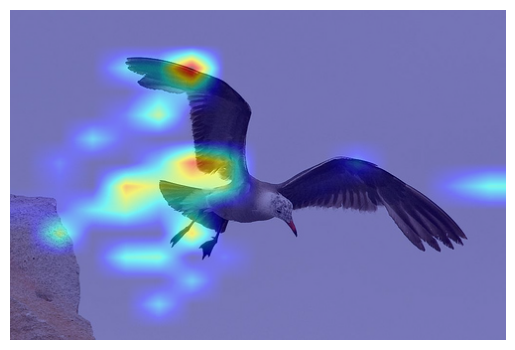

In [25]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

# FinerCAM Setup. Target layer: (last block norm)
target_layers = [model.backbone.blocks[-1].norm1]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

True label: 60
Predicted: 629


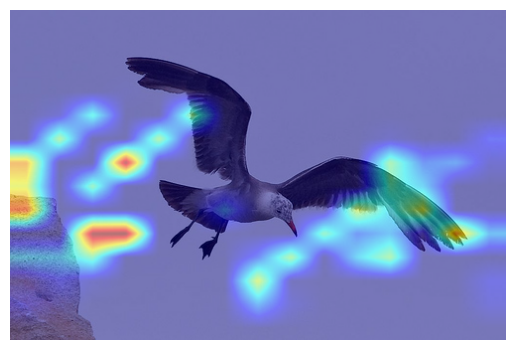

In [26]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

# FinerCAM Setup. Target layer: (last block norm)
target_layers = [model.backbone.blocks[-1].norm2]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

Convnext_nano

True label: 60
Predicted: 142
True label: 60
Predicted: 142


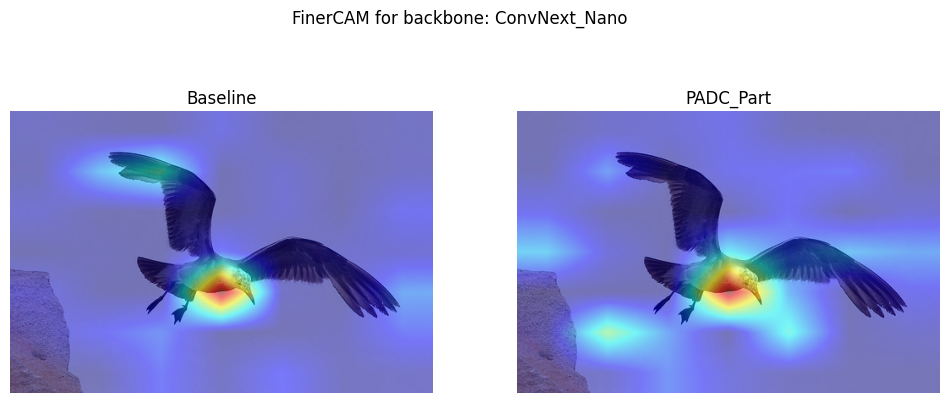

In [27]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

classifier_name = "ConvNext_Nano"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.stages[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.stages[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

DeiT

True label: 60
Predicted: 64
True label: 60
Predicted: 64


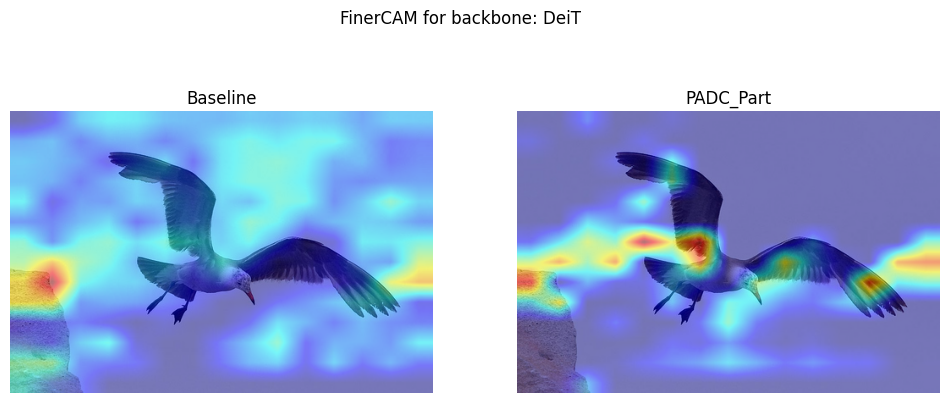

In [28]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "DeiT"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.blocks[-1].norm2]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.blocks[-1].norm2]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 60
Predicted: 70
True label: 60
Predicted: 70


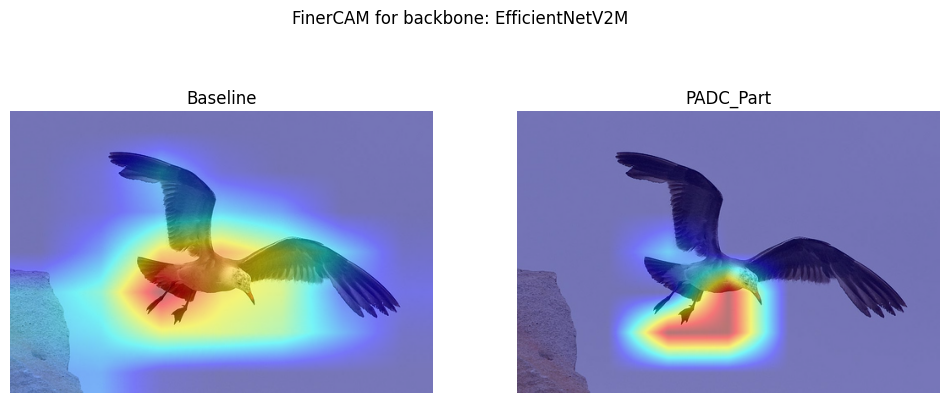

In [30]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "EfficientNetV2M"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.conv_head]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.conv_head]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 60
Predicted: 43
True label: 60
Predicted: 142


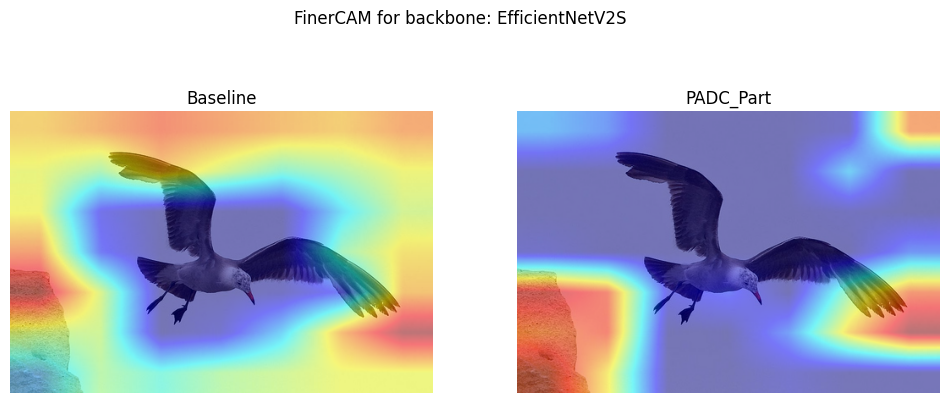

In [31]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "EfficientNetV2S"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.conv_head]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.conv_head]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 60
Predicted: 70


/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/torch/nn/init.py:566: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


True label: 60
Predicted: 70


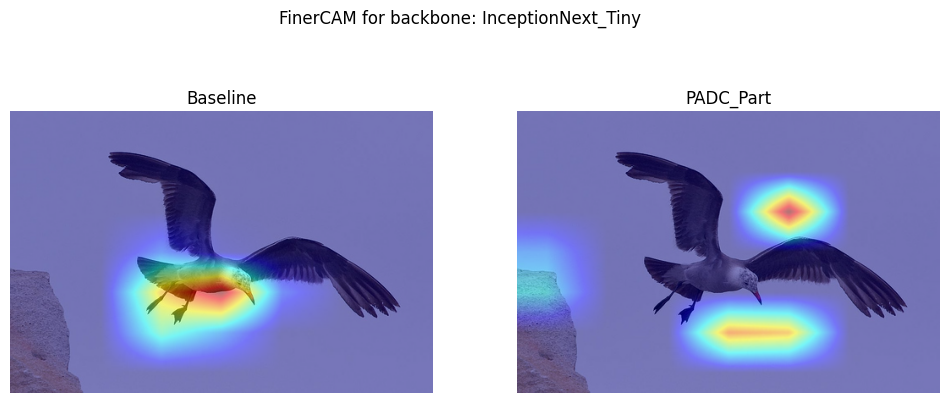

In [32]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "InceptionNext_Tiny"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.stages[-1].blocks[-1].norm]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.stages[-1].blocks[-1].norm]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 60
Predicted: 142
True label: 60
Predicted: 142


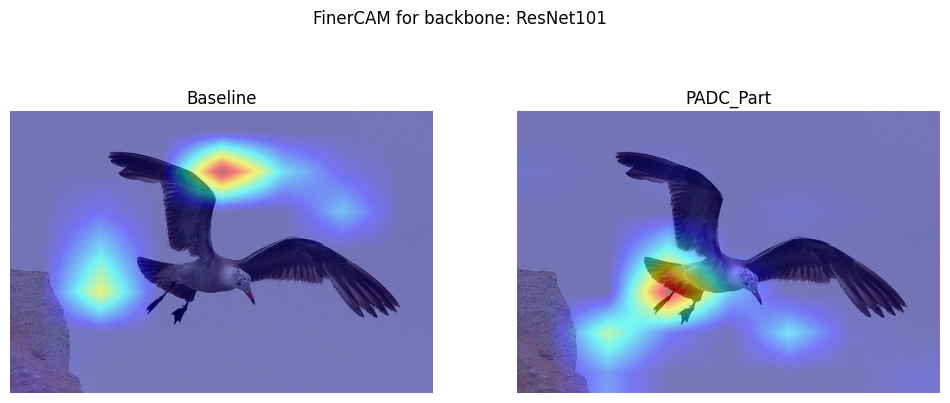

In [33]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "ResNet101"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.layer4[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.layer4[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 60
Predicted: 142
True label: 60
Predicted: 142


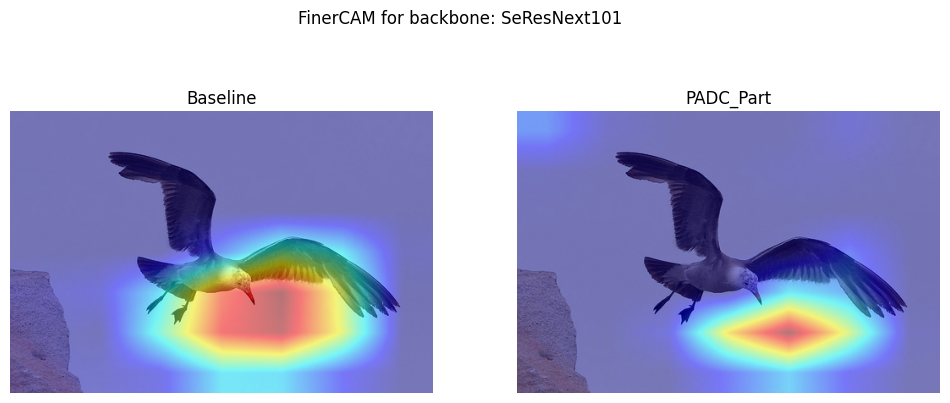

In [34]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "SeResNext101"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.layer4[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.layer4[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 60
Predicted: 60
True label: 60
Predicted: 142


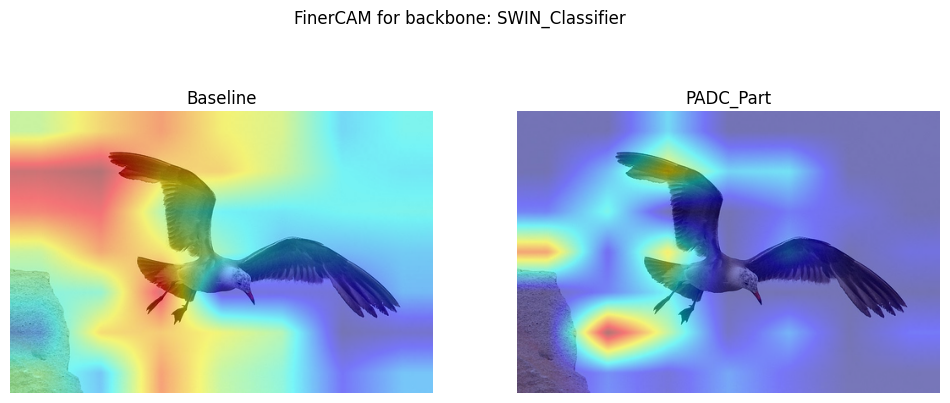

In [35]:
# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]
classifier_name = "SWIN_Classifier"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.layers[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.layers[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.9)
plt.show()

True label: 27
Predicted: 27
True label: 27
Predicted: 27


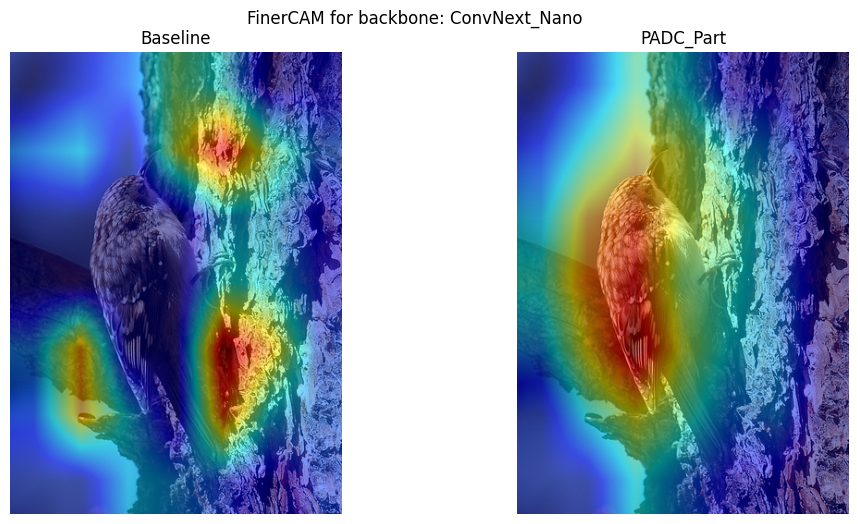

In [37]:
# Select one test image
image_no = 77
image, lbl, img_path = test_dataset[image_no]

classifier_name = "ConvNext_Nano"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.stages[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.stages[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.95)
plt.show()

True label: 27
Predicted: 27
True label: 27
Predicted: 27


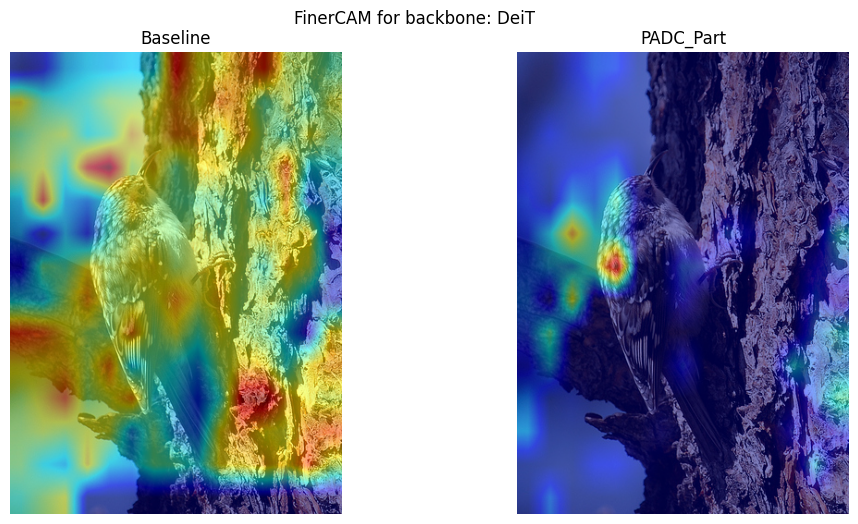

In [43]:
# Select one test image
image_no = 77
image, lbl, img_path = test_dataset[image_no]
classifier_name = "DeiT"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.blocks[-1].norm2]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.blocks[-1].norm2]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.95)
plt.show()

True label: 27
Predicted: 27
True label: 27
Predicted: 27


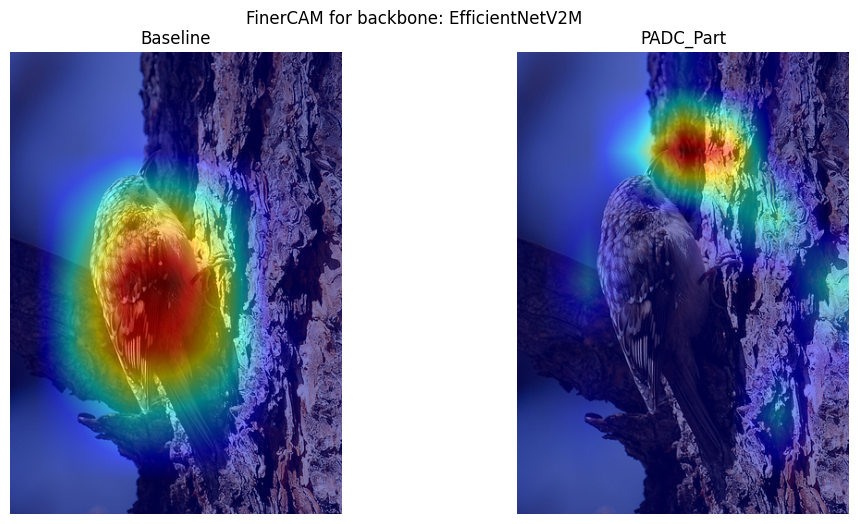

In [40]:
# Select one test image
image_no = 77
image, lbl, img_path = test_dataset[image_no]
classifier_name = "EfficientNetV2M"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.conv_head]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.conv_head]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.95)
plt.show()

True label: 27
Predicted: 27
True label: 27
Predicted: 27


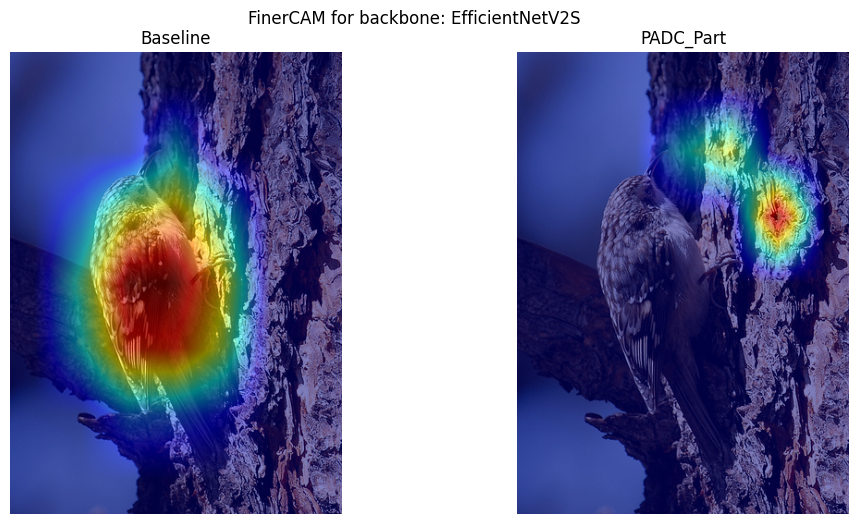

In [42]:
# Select one test image
image_no = 77
image, lbl, img_path = test_dataset[image_no]
classifier_name = "EfficientNetV2S"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.conv_head]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.conv_head]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.95)
plt.show()

True label: 27
Predicted: 27
True label: 27
Predicted: 27


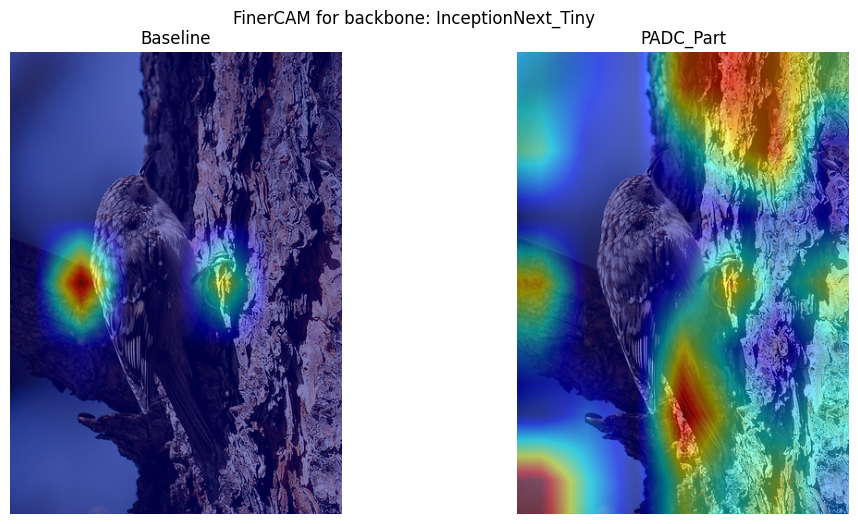

In [45]:
# Select one test image
image_no = 77
image, lbl, img_path = test_dataset[image_no]
classifier_name = "InceptionNext_Tiny"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.stages[-1].blocks[-1].norm]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.stages[-1].blocks[-1].norm]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.95)
plt.show()

True label: 27
Predicted: 27
True label: 27
Predicted: 27


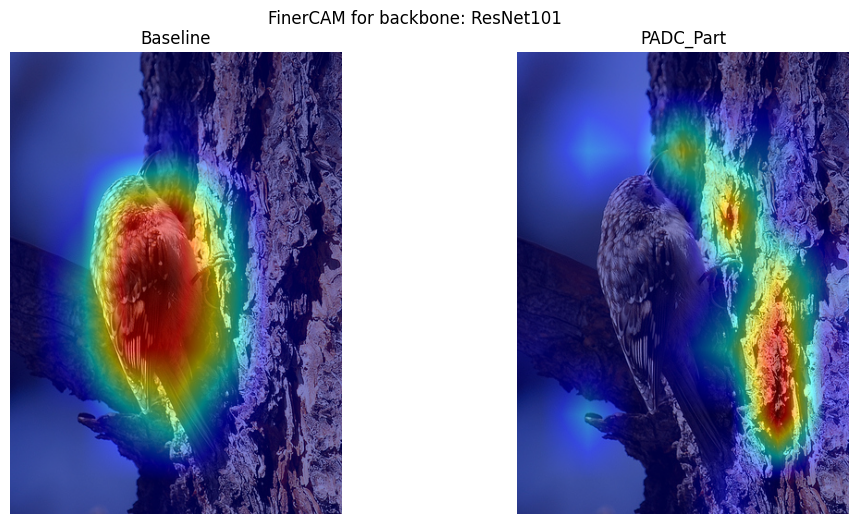

In [52]:
# Select one test image
image_no = 77
image, lbl, img_path = test_dataset[image_no]
classifier_name = "ResNet101"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.layer4[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.layer4[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.95)
plt.show()

True label: 27
Predicted: 27
True label: 27
Predicted: 27


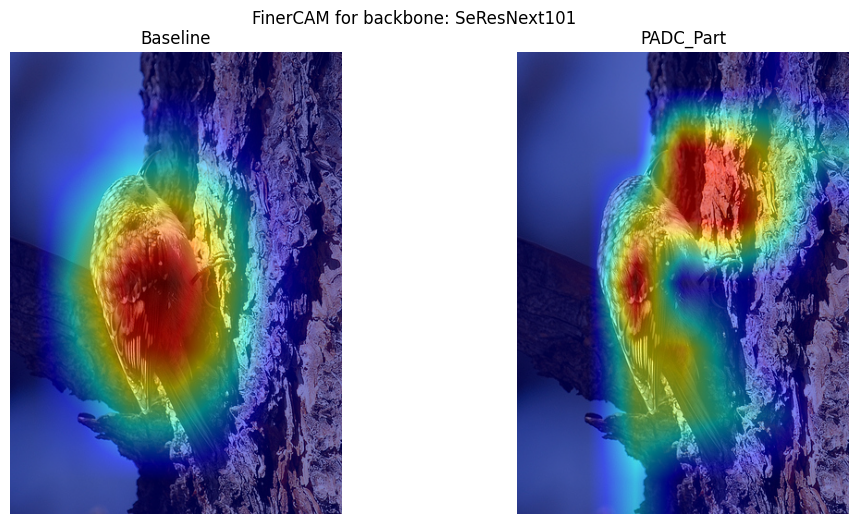

In [49]:
# Select one test image
image_no = 77
image, lbl, img_path = test_dataset[image_no]
classifier_name = "SeResNext101"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.layer4[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.layer4[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.95)
plt.show()

True label: 27
Predicted: 27
True label: 27
Predicted: 27


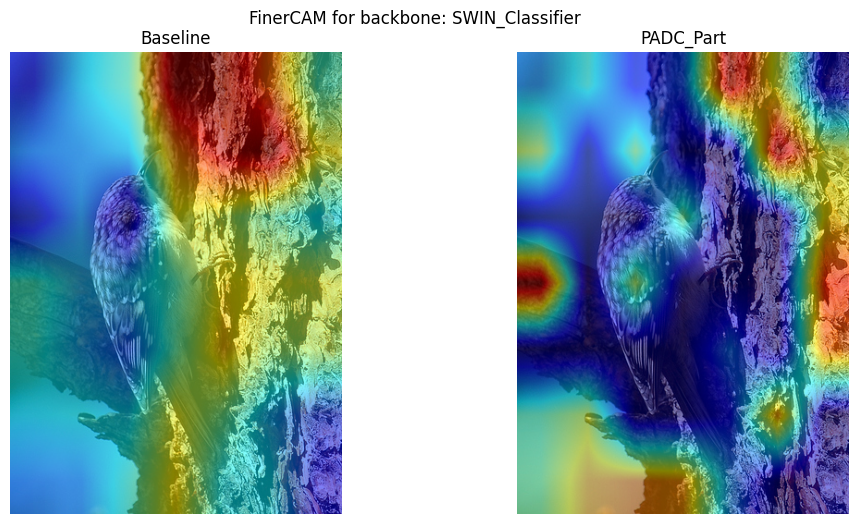

In [51]:
# Select one test image
image_no = 77
image, lbl, img_path = test_dataset[image_no]
classifier_name = "SWIN_Classifier"
device = torch.device(f"cuda:{DEVICE_ID}")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Load baseline model
baseline_state_dict = torch.load(baseline_weights[classifier_name], map_location=device)
baseline_model = timm.create_model(
        backbone_models[classifier_name],
        pretrained=False,
        num_classes=num_classes
    )
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.to(device)
baseline_model.eval()
baseline_target_layers = [baseline_model.layers[-1]]
baseline_cam = FinerCAM(
    model=baseline_model,
    target_layers=baseline_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=baseline_model, 
         img_path=img_path, label=lbl, 
         cam_method=baseline_cam, 
         transform=test_dataset.transform, 
         ax=axes[0])
axes[0].set_title("Baseline")


# Load PADC model
padc_state_dict = torch.load(padc_weights[classifier_name], map_location=device)
padc_model = DeepShapeFusionModel(num_classes=num_classes, 
                                  classifier_name=backbone_models[classifier_name], 
                                  shape_embed_dim=512)
padc_model.load_state_dict(padc_state_dict)
padc_model.to(device)
padc_model.eval()
padc_target_layers = [padc_model.backbone.layers[-1]]
padc_cam = FinerCAM(
    model=padc_model, # Full PADC model
    target_layers=padc_target_layers,
    reshape_transform=get_reshape_transform(classifier_name)
)
plot_cam(model=padc_model, # Full PADC model
         img_path=img_path, label=lbl, 
         cam_method=padc_cam, 
         transform=test_dataset.transform, 
         ax=axes[1])
axes[1].set_title("PADC_Part")
fig.suptitle(f'FinerCAM for backbone: {classifier_name}', y=0.95)
plt.show()